In [2]:
# reload module automatically when edited
%load_ext autoreload
%autoreload 2
from IAR_PROJET import *
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import cv2
from IPython.display import Video

---
# Environment Class
---

### Initialize and display Environment

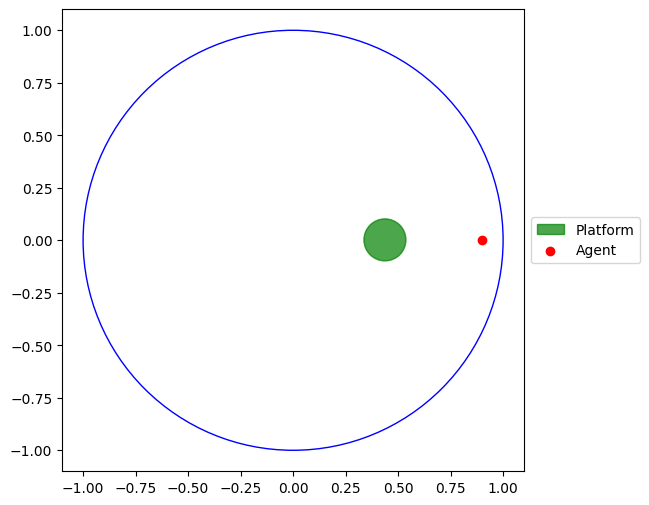

In [2]:
env = Environment()
env.display()

### Reset environment with RMW (platform stays in place)

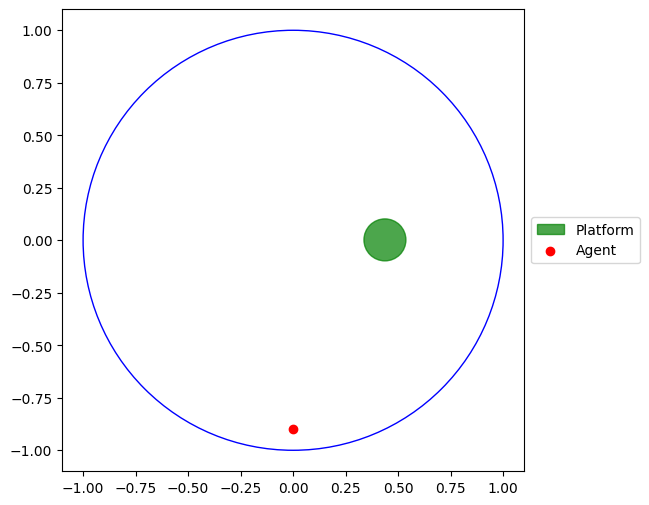

In [3]:
env.reset("RMW")
env.display()

### Reset Environment with DMP (platform is moved randomly)

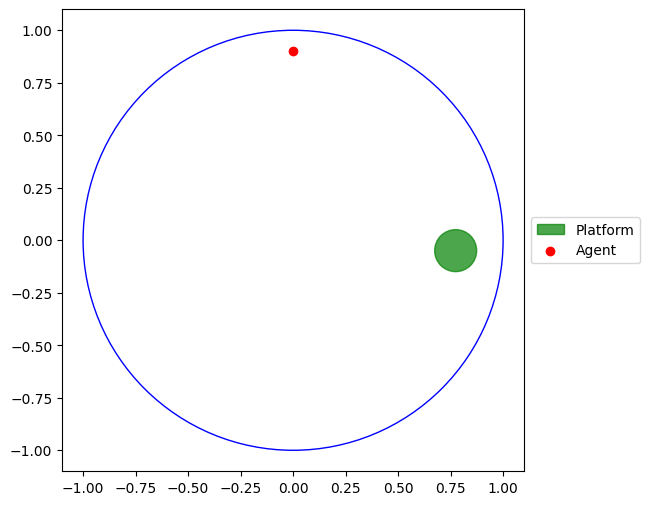

In [4]:
env.reset("DMP")
env.display()

### Step Function

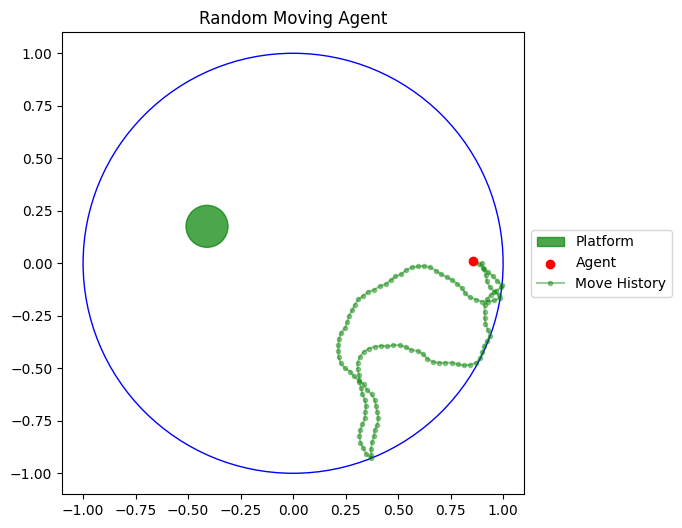

In [5]:
demoenv = DemoEnv()

max_steps = 120
fps = 20
start_pos = None
move_dir = None

demoenv.step_function_demo(max_steps=max_steps, fps=fps,
                                    start_pos=start_pos, move_dir=move_dir,
                                    save_path="animation_random.mp4",
                                    title="Random Moving Agent")
Video("animation_random.mp4", embed=True)

---
# Place Cells
---

(493, 2)


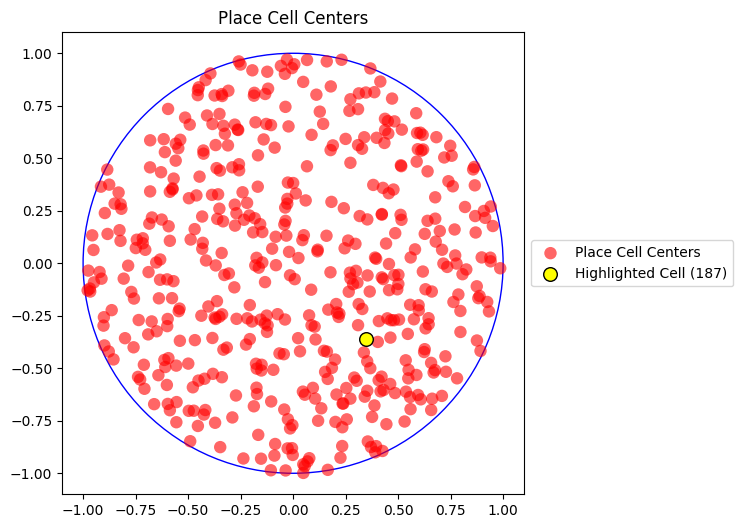

In [66]:
env = Environment()
place_cells = PlaceCells(env, n_cells=493, sigma=0.16)
print(place_cells.centers.shape)
selected_place_cell_id = np.random.randint(0, place_cells.n_cells)
place_cells.display_centers(highlight_id=selected_place_cell_id)

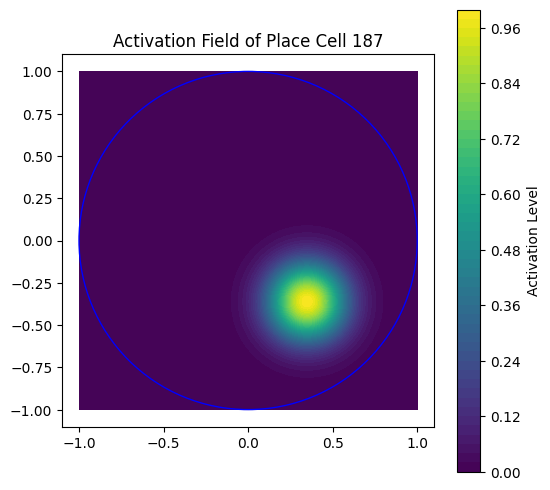

In [67]:
place_cells.display_activation_field(selected_place_cell_id, grid_size=100)

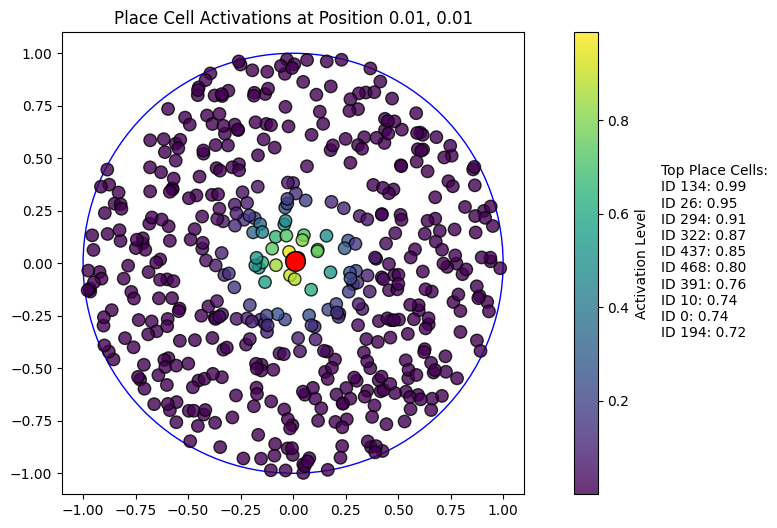

In [84]:
place_cells.display_all_place_activation_by_location()

---
# TD Agent Class
---

Trial 1: 


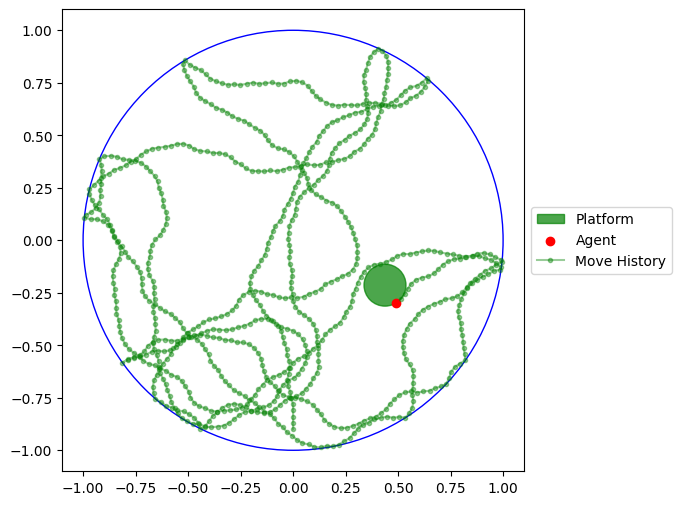

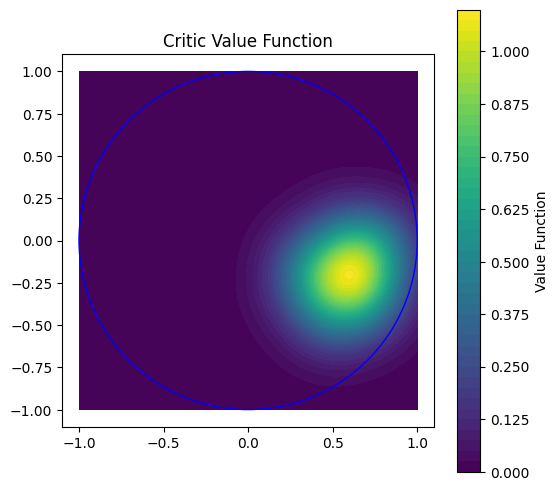

Trial 100: 


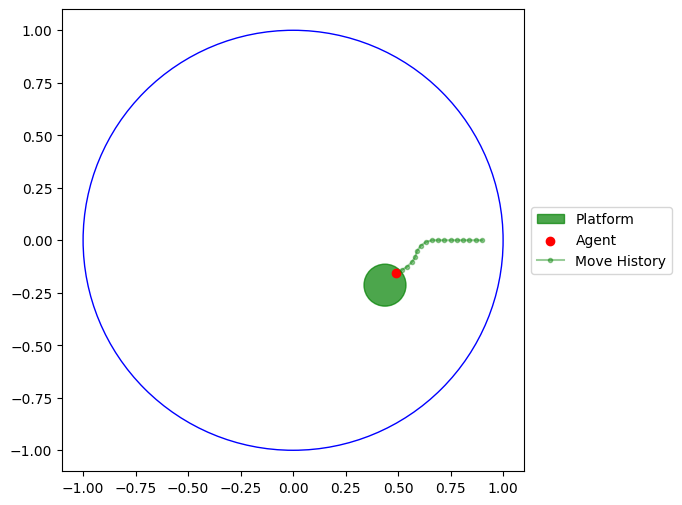

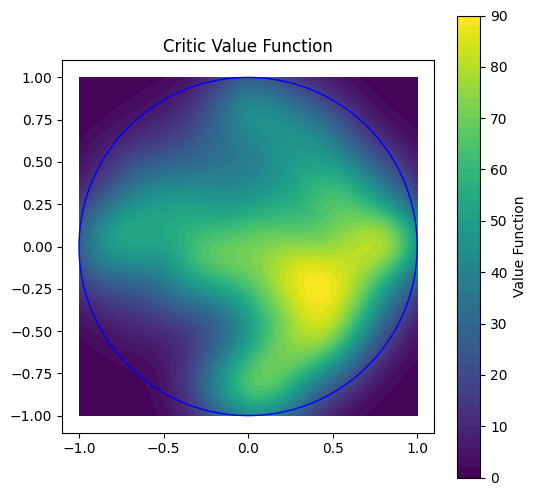

In [126]:
env = Environment()
agent = TD_Agent(env)
print(f"Trial 1: ")
_ = agent.run_trial("RMW")
env.display()
agent.critic.display_value_function()
trial_mode = "RMW"
for _ in range(99):
    _ = agent.run_trial(trial_mode)
print(f"Trial 100: ")
env.display()
agent.critic.display_value_function()

---
# Figure 3
---

In [134]:
env = Environment()
agent = TD_Agent(env)
trial_mode = "RMW"

### Trial 2:

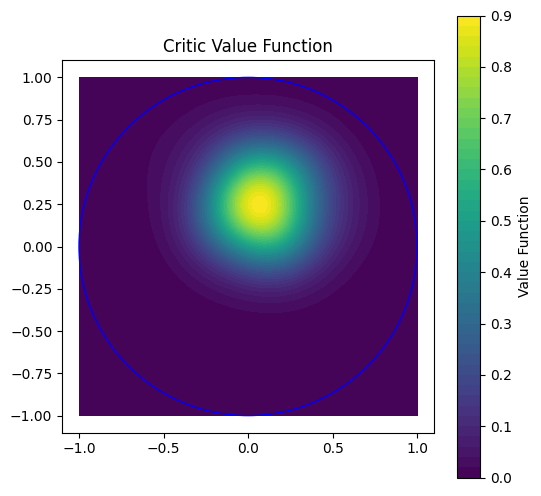

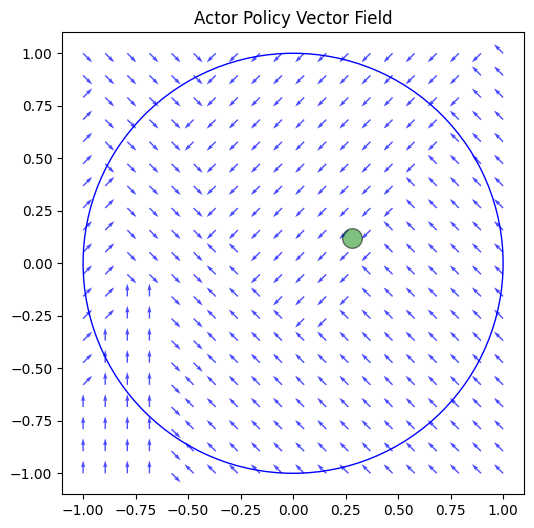

Steps: 195, Path Length: 5.85, Time: 19.50s, Done: True


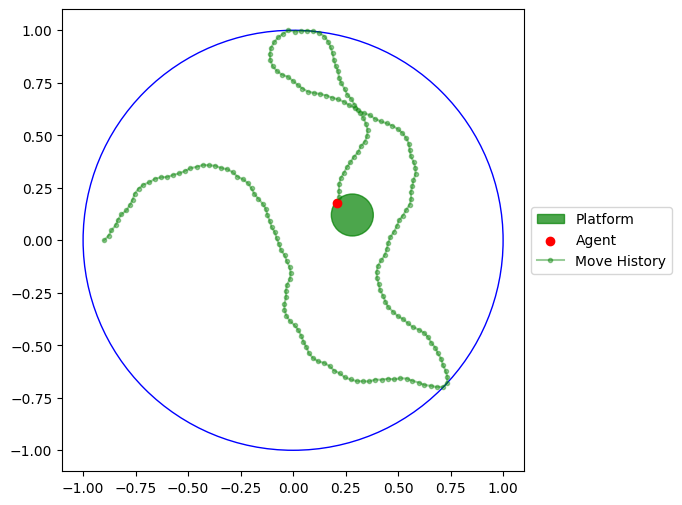

In [135]:
temp = agent.run_trial(trial_mode)
# Critic Value Field Graph
agent.critic.display_value_function()
# Actor Vector Field Graph
agent.actor.display_policy()

steps, path_length, trial_time, done = agent.run_trial(trial_mode)
print(f"Steps: {steps}, Path Length: {path_length:.2f}, Time: {trial_time:.2f}s, Done: {done}")
env.display()

### Trial 7:

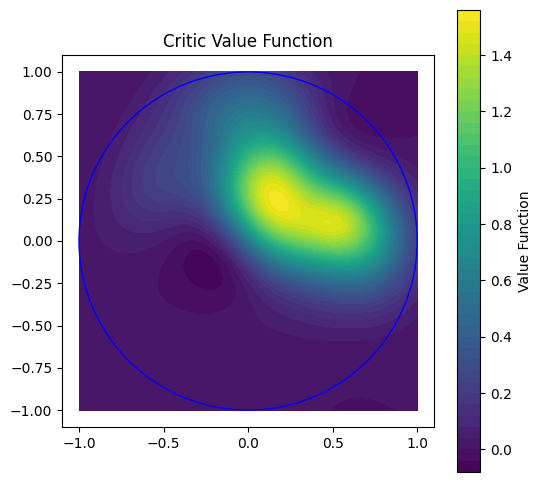

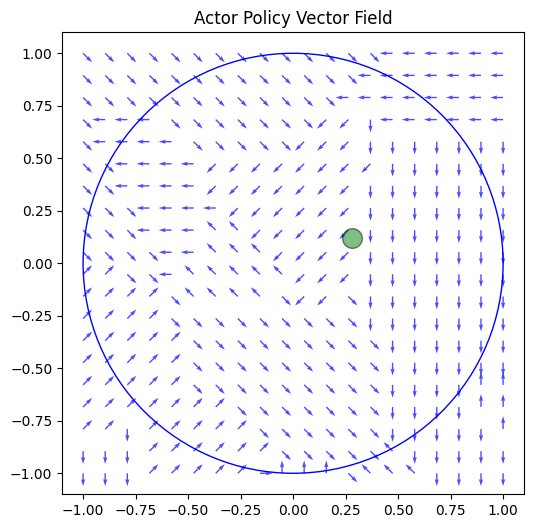

Steps: 52, Path Length: 1.56, Time: 5.20s, Done: True


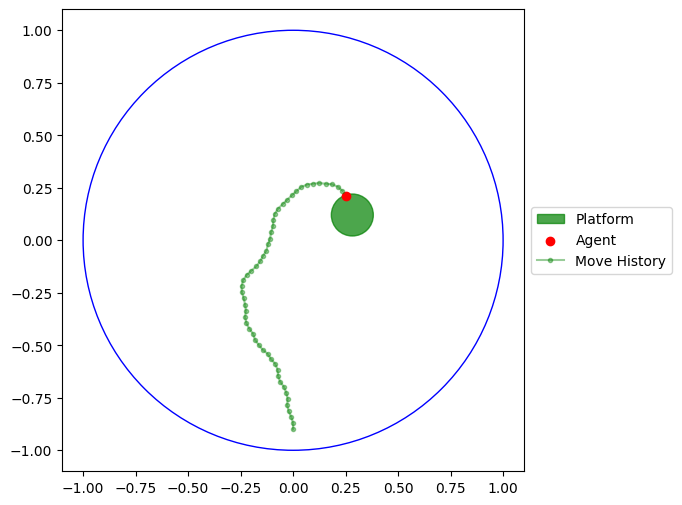

In [136]:
temp = agent.run_trial(trial_mode)
# Critic Value Field Graph
agent.critic.display_value_function()
# Actor Vector Field Graph
agent.actor.display_policy()

for i in range(4):
    _ = agent.run_trial(trial_mode)
steps, path_length, trial_time, done = agent.run_trial(trial_mode)
print(f"Steps: {steps}, Path Length: {path_length:.2f}, Time: {trial_time:.2f}s, Done: {done}")
env.display()

### Trial 22:

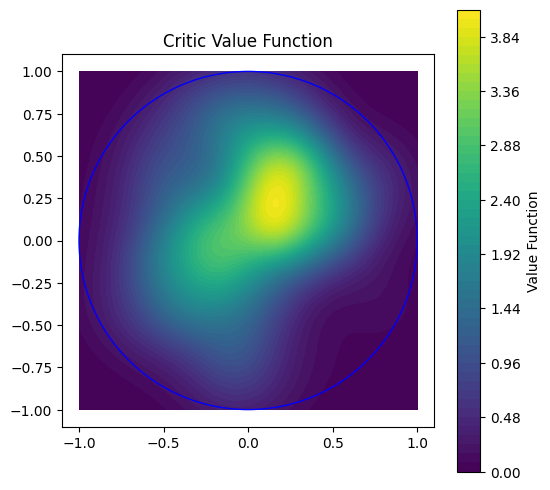

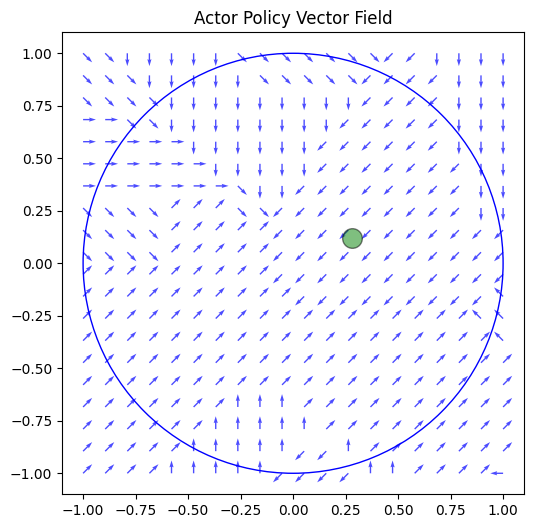

Steps: 51, Path Length: 1.52, Time: 5.10s, Done: True


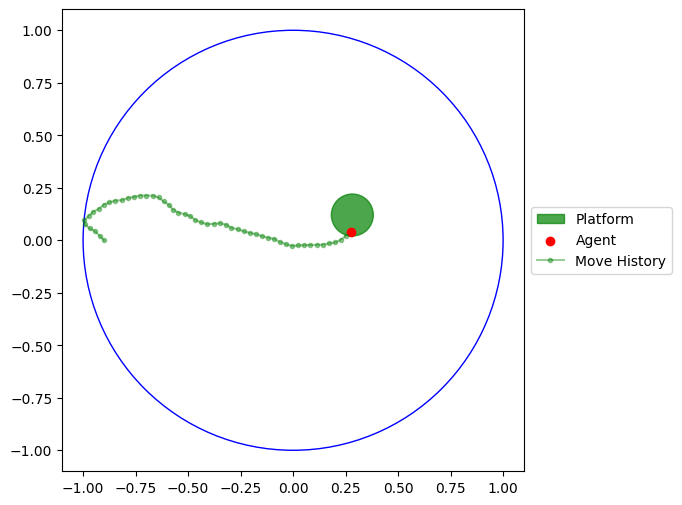

In [137]:
temp = agent.run_trial(trial_mode)
# Critic Value Field Graph
agent.critic.display_value_function()
# Actor Vector Field Graph
agent.actor.display_policy()

for i in range(14):
    _ = agent.run_trial(trial_mode)
steps, path_length, trial_time, done = agent.run_trial(trial_mode)
print(f"Steps: {steps}, Path Length: {path_length:.2f}, Time: {trial_time:.2f}s, Done: {done}")
env.display()

---
# Figure 4
---

## Figure 4.a

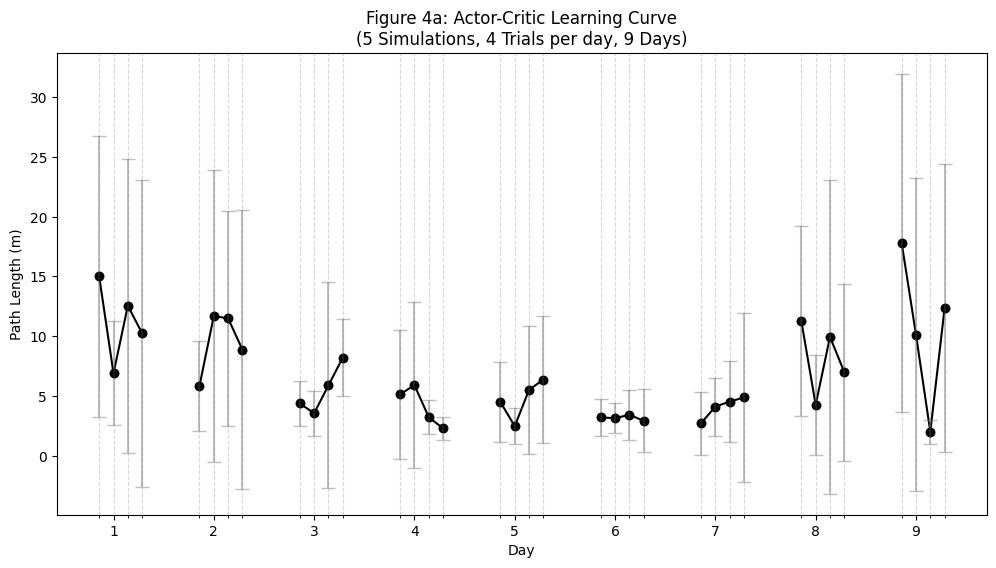

In [223]:
env = Environment()
agent = TD_Agent(env)

trials_by_day = ["RMW"] * 7 + ["DMP"] + ["RMW"]
trials_per_day = 4
simulation_count = 5

results_4a = agent.run_figure4(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day)
agent.display_figure4(results_4a)

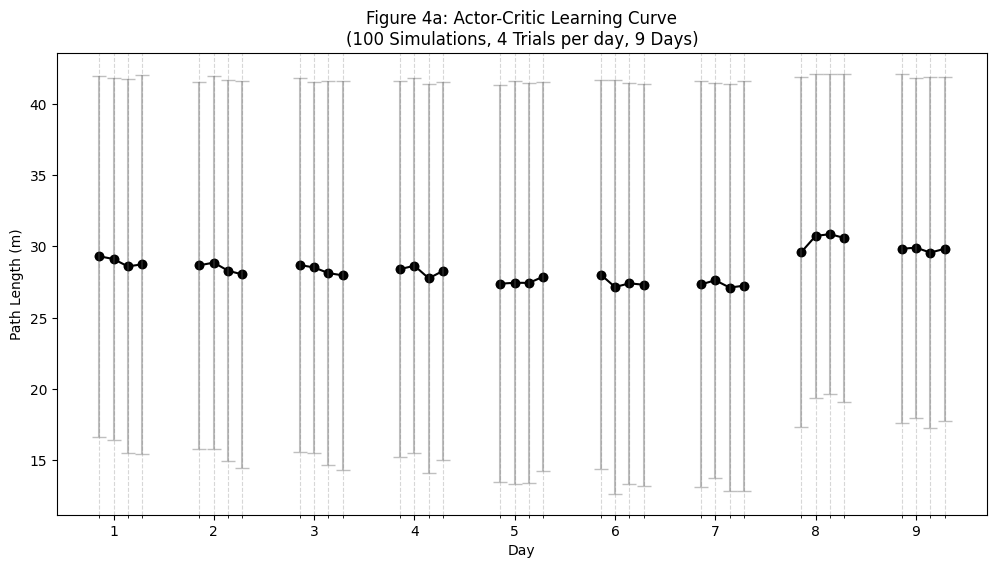

In [208]:
env = Environment()
agent = TD_Agent(env)

trials_by_day = ["RMW"] * 7 + ["DMP"] + ["RMW"]
trials_per_day = 4
simulation_count = 100

results_4a = agent.run_figure4(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day)
agent.display_figure4(results_4a)

In [221]:
data = np.array(results_4a)
path_lengths = data[:, :, :, 1]
path_lengths[40]

array([[35.77892023, 35.74727235, 35.71066122, 35.72619833],
       [35.71281791, 35.759577  , 35.76093172, 35.71287268],
       [35.70988952, 35.73459477, 35.7306624 , 35.74040221],
       [35.75356519, 35.71274087, 35.75255418, 35.73271158],
       [35.738569  , 35.76027603, 35.74409404, 35.7222949 ],
       [35.69889996, 35.74778972, 35.69625257, 35.73557623],
       [35.73467965, 35.74307882, 35.74187177, 35.73083961],
       [35.72296291, 35.71062836, 35.7447202 , 35.74512216],
       [35.69731565, 35.7588141 , 35.72517579, 35.7263426 ]])

In [ ]:
env = Environment()
agent = TD_Agent(env)

trials_by_day = ["DMP"] * 9
trials_per_day = 4
simulation_count = 1

results_4b = agent.run_figure4(simulation_count=simulation_count, trials_by_day=trials_by_day, trials_per_day=trials_per_day)
agent.display_figure4(results_4b)

Starting Simulation 0...
Starting Simulation 10...
Starting Simulation 20...
Starting Simulation 30...
Starting Simulation 40...
Starting Simulation 50...
Starting Simulation 60...
Starting Simulation 70...
Starting Simulation 80...
Starting Simulation 90...


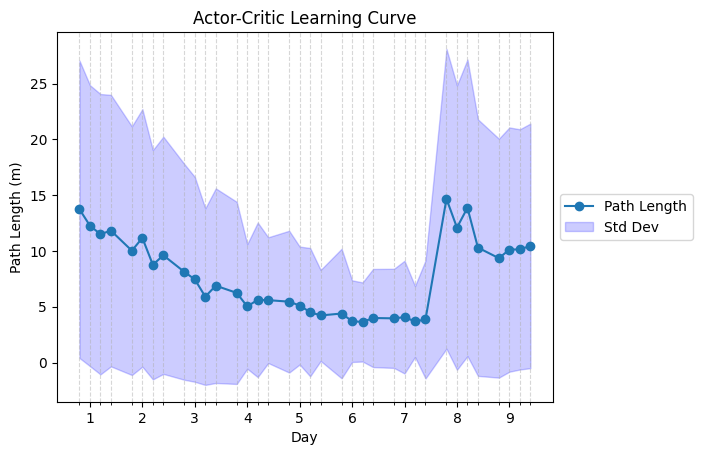

In [ ]:
# PARAMS
trial_modes_by_day = ["RMW"] * 7 + ["DMP"] + ["RMW"]
simulation_count = 100
trial_per_day = 4
day_count = 9

path_lengths = figure4(trial_modes_by_day, simulation_count, trial_per_day, day_count)

Starting Simulation 0...
Starting Simulation 10...
Starting Simulation 20...
Starting Simulation 30...
Starting Simulation 40...
Starting Simulation 50...
Starting Simulation 60...
Starting Simulation 70...
Starting Simulation 80...
Starting Simulation 90...


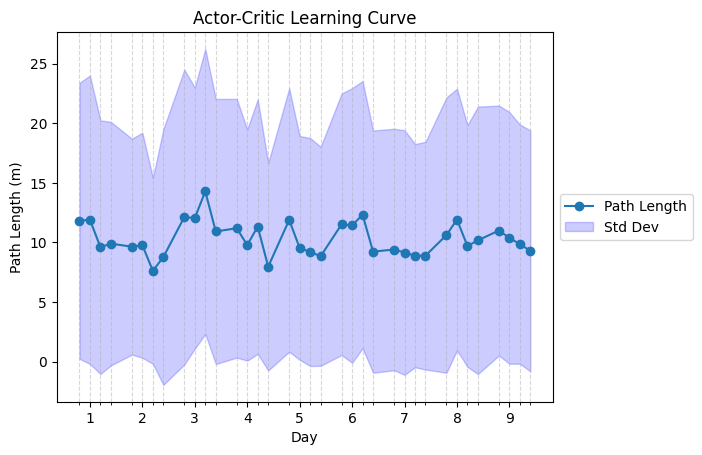

In [66]:
# PARAMS
trial_modes_by_day = ["DMP"] * 9
simulation_count = 100
trial_per_day = 4
day_count = 9

path_lengths = figure4(trial_modes_by_day, simulation_count, trial_per_day, day_count)

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def figure3(trial_checkpoints=[2, 7, 22]):
    """
    Reproduces Figure 3: Value Function, Vector Field, and Path 
    at specific stages of learning.
    """
    # 1. Setup Simulation
    env = Environment()
    # We use RMW (Fixed Platform) as per the Figure description
    env.set_platform_position([0.5, 0.5]) 
    
    # Use the TUNED parameters for a good demo
    agent = TD_Agent(env, learning_rate=0.1, discount_factor=0.99, lambda_param=0.9)
    agent.place_cells.sigma = 0.3 

    # Prepare the Visualization Grid (for 3D and Quiver plots)
    resolution = 30
    x = np.linspace(-1.0, 1.0, resolution)
    y = np.linspace(-1.0, 1.0, resolution)
    X, Y = np.meshgrid(x, y)
    
    # Create the Master Figure
    # Layout: Rows = Metrics (Value, Policy, Path), Cols = Trials
    fig = plt.figure(figsize=(15, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    
    current_col_idx = 1
    
    print("Starting Simulation for Figure 3...")

    # Run up to the max required trial
    max_trial = max(trial_checkpoints)
    
    for trial in range(1, max_trial + 1):
        # Run the trial
        steps, path_len, time, success = agent.run_trial(mode="RMW")
        
        # Check if we need to snapshot this trial
        if trial in trial_checkpoints:
            print(f"Snapshotting Trial {trial}...")
            
            # --- 1. Top Row: 3D Value Function ---
            ax_val = fig.add_subplot(3, 3, current_col_idx, projection='3d')
            
            # Compute Value Map Z
            Z = np.zeros_like(X)
            for i in range(resolution):
                for j in range(resolution):
                    pos = np.array([X[i,j], Y[i,j]])
                    if np.linalg.norm(pos) <= env.radius:
                        # Get brain activity at this specific grid point
                        acts = agent.place_cells.get_activation(pos)
                        # Ask Critic for value
                        Z[i,j] = agent.get_value(acts)
                    else:
                        Z[i,j] = np.nan # Mask outside pool

            # Plot Surface
            surf = ax_val.plot_surface(X, Y, Z, cmap=cm.viridis, linewidth=0, antialiased=False)
            ax_val.set_title(f"Trial {trial}: Value Function")
            ax_val.set_zlim(0, 1.0) # Values are between 0 and 1
            ax_val.axis('off')

            # --- 2. Middle Row: Policy (Quiver) ---
            ax_pol = fig.add_subplot(3, 3, current_col_idx + 3)
            
            # Draw Pool Boundary
            circle = plt.Circle((0, 0), env.radius, color='k', fill=False)
            ax_pol.add_artist(circle)
            
            # Compute Vector Field
            U = np.zeros_like(X)
            V = np.zeros_like(X)
            
            for i in range(resolution):
                for j in range(resolution):
                    pos = np.array([X[i,j], Y[i,j]])
                    if np.linalg.norm(pos) <= env.radius * 0.9: # Stay slightly inside
                        acts = agent.place_cells.get_activation(pos)
                        probs, _ = agent.get_action_probabilities(acts)
                        
                        # Calculate Weighted Average Vector
                        # Sum(Probability * DirectionVector)
                        avg_vec = np.sum(probs[:, np.newaxis] * agent.action_vectors, axis=0)
                        
                        U[i,j] = avg_vec[0]
                        V[i,j] = avg_vec[1]
            
            # Plot Quiver
            ax_pol.quiver(X, Y, U, V, scale=20, pivot='mid')
            ax_pol.set_title(f"Trial {trial}: Preferred Actions")
            ax_pol.set_aspect('equal')
            ax_pol.axis('off')
            
            # --- 3. Bottom Row: Sample Path ---
            ax_path = fig.add_subplot(3, 3, current_col_idx + 6)
            
            # Draw Pool and Goal
            circle = plt.Circle((0, 0), env.radius, color='b', fill=False)
            goal = plt.Circle(env.platform_pos, env.platform_radius, color='g', alpha=0.5)
            ax_path.add_artist(circle)
            ax_path.add_artist(goal)
            
            # Plot Path
            if len(env.move_history) > 0:
                hist = np.array(env.move_history)
                ax_path.plot(hist[:,0], hist[:,1], color='k', linewidth=1)
            
            ax_path.set_title(f"Trial {trial}: Path ({path_len:.2f}m)")
            ax_path.set_xlim(-1.1, 1.1)
            ax_path.set_ylim(-1.1, 1.1)
            ax_path.set_aspect('equal')
            ax_path.axis('off')
            
            current_col_idx += 1

    plt.suptitle("Replication of Figure 3 (Foster et al., 2000)", fontsize=16)
    plt.show()


Starting Simulation for Figure 3...
Snapshotting Trial 2...
Snapshotting Trial 7...
Snapshotting Trial 22...


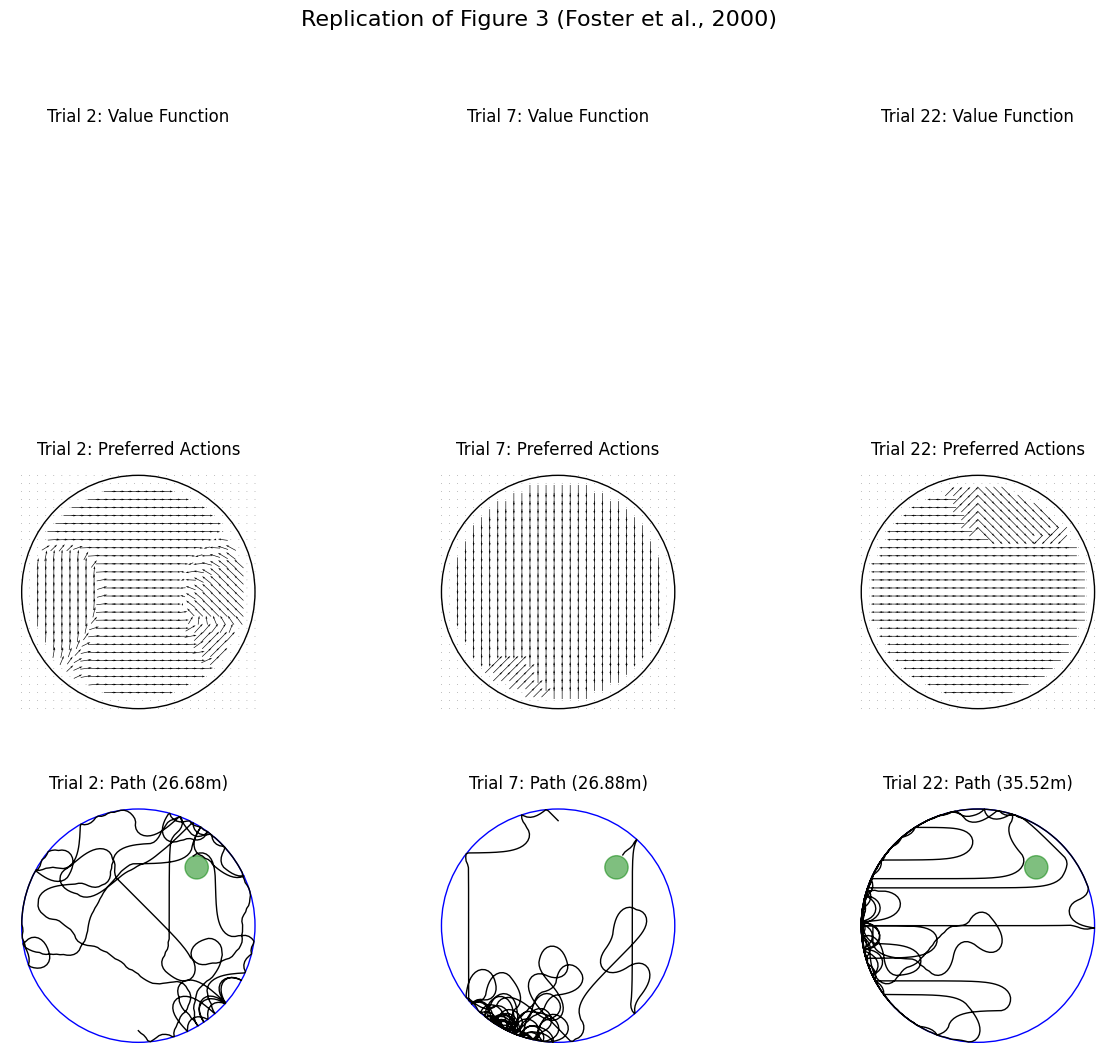

In [ ]:
figure3()